
# Neuronales Netz 09: Dreischichtiges Netz mit Matrizenmultiplikation

## Von einer Matrixrechnung zu drei Schichten

In Colab 07 hast du gesehen:

$X = W \cdot I$

In Python schreiben wir:

```python
X = W @ I
```

Heute verwenden wir diese Idee für ein neuronales Netz mit **drei Schichten**.

Das Netz hat:

1. eine **Eingabeschicht**
2. eine **versteckte Schicht**
3. eine **Ausgabeschicht**

Das Ziel:

> Du siehst Schritt für Schritt, wie ein Signal durch drei Schichten wandert.



## 1. Was ist eine versteckte Schicht?

Die versteckte Schicht liegt **zwischen** Eingabe und Ausgabe.

Sie ist nicht geheim.

Sie heisst versteckt, weil wir ihre Werte am Ende oft nicht direkt sehen.
Wir sehen meistens nur die letzte Ausgabe.

Die versteckte Schicht macht aber wichtige Arbeit:

- Sie nimmt die Eingaben auf.
- Sie verrechnet sie mit Gewichten.
- Sie gibt neue Werte weiter.

Diese neuen Werte gehen dann in die Ausgabeschicht.



## 2. Bibliotheken laden

Wir verwenden wieder:

- `numpy` für Matrizen und Rechnungen
- `pandas` für Tabellen
- `matplotlib` für Bilder

Die Namen der Variablen sind in Englisch.
So sind sie im Code gut lesbar.


In [ ]:
#@title Import starten { display-mode: "form" }
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.set_option("display.max_columns", 20)


## 3. Hilfsfunktionen

Wir brauchen zwei kleine Hilfsfunktionen.

Die erste Funktion zeigt Matrizen als Tabelle.

Die zweite Funktion ist die Sigmoid-Funktion.


In [ ]:
#@title Hilfsfunktionen laden { display-mode: "form" }
def as_matrix_table(matrix, row_prefix="Zeile", col_prefix="Spalte", decimals=3):
    """Gibt eine Matrix als pandas-Tabelle zurück."""
    matrix = np.array(matrix, dtype=float)
    n_rows, n_cols = matrix.shape
    data = np.round(matrix, decimals)
    row_names = [f"{row_prefix} {i + 1}" for i in range(n_rows)]
    col_names = [f"{col_prefix} {j + 1}" for j in range(n_cols)]
    return pd.DataFrame(data, index=row_names, columns=col_names)


def sigmoid(x):
    """Sigmoid-Funktion. Sie macht aus Zahlen Werte zwischen 0 und 1."""
    return 1 / (1 + np.exp(-x))


## 4. Die Eingabematrix

Wir starten mit drei Eingaben.

Die Eingaben stehen als Spaltenmatrix da:

$I =
\begin{bmatrix}
0.9 \\
0.1 \\
0.8
\end{bmatrix}$

Das bedeutet:

- Eingang 1 hat den Wert 0.9
- Eingang 2 hat den Wert 0.1
- Eingang 3 hat den Wert 0.8


In [ ]:
#@title Tabellen: Eingaben{ display-mode: "form" }
I = np.array([
    [0.9],
    [0.1],
    [0.8],
])

display(as_matrix_table(I, row_prefix="Eingang", col_prefix="Wert", decimals=1))
print(f"Form von I: {I.shape[0]}x{I.shape[1]}")

,Wert 1
Eingang 1,0.9
Eingang 2,0.1
Eingang 3,0.8


Form von I: 3x1



## 5. Die erste Gewichtsmatrix

Jeder Pfeil im Netz hat ein Gewicht.

Viele Pfeile sind schnell unübersichtlich.
Darum schreiben wir alle Gewichte in eine Matrix.

Die erste Gewichtsmatrix heisst hier:

$W_{input\_hidden}$

Sie enthält die Gewichte von der **Eingabeschicht** zur **versteckten Schicht**.

Wichtig:

> Eine Zeile gehört zu einem Zielneuron in der nächsten Schicht.

Beispiel:

Die erste Zeile gehört zum versteckten Neuron 1.
Sie sagt, wie stark die drei Eingänge zu diesem Neuron kommen.


In [ ]:
#@title Tabelle: Gewichte pro Neuron (Zeile) { display-mode: "form" }
W_input_hidden = np.array([
    [0.9, 0.3, 0.4],
    [0.2, 0.8, 0.2],
    [0.1, 0.5, 0.6],
])

display(as_matrix_table(W_input_hidden,
                        row_prefix="Ziel H", col_prefix="Start I", decimals=1))
print(f"Form von W_input_hidden: {W_input_hidden.shape[0]}x{W_input_hidden.shape[1]}")

,Start I 1,Start I 2,Start I 3
Ziel H 1,0.9,0.3,0.4
Ziel H 2,0.2,0.8,0.2
Ziel H 3,0.1,0.5,0.6


Form von W_input_hidden: 3x3



## 6. Passt die Matrizenmultiplikation?

Wir rechnen:

$X_{hidden} = W_{input\_hidden} \cdot I$

Die Grössen sind:

$3 \times 3 \cdot 3 \times 1 = 3 \times 1$

Die inneren Zahlen sind gleich:

$3 \times \underline{3} \cdot \underline{3} \times 1$

Darum ist die Rechnung erlaubt.

Die äusseren Zahlen geben die neue Grösse:

$3 \times 1$


In [ ]:
#@title Tabelle: Rohwerte der versteckten Schicht { display-mode: "form" }
X_hidden = W_input_hidden @ I

display(as_matrix_table(X_hidden, row_prefix="X hidden", col_prefix="Wert", decimals=3))
print(f"Form von X_hidden: {X_hidden.shape[0]}x{X_hidden.shape[1]}")

,Wert 1
X hidden 1,1.16
X hidden 2,0.42
X hidden 3,0.62


Form von X_hidden: 3x1



## 7. Was bedeutet $X_{\text{hidden}}$?

$X_{\text{hidden}}$ sind die **rohen Summen** für die versteckte Schicht.

Roh bedeutet:

- Die Gewichte wurden schon benutzt.
- Die Werte wurden addiert.
- Die Sigmoid-Funktion wurde noch **nicht** benutzt.

Für das erste versteckte Neuron sieht die Rechnung so aus:

$x_{hidden,1} = 0.9 \cdot 0.9 + 0.3 \cdot 0.1 + 0.4 \cdot 0.8$

Also:

$x_{hidden,1} = 1.16$


In [ ]:
#@title Berechnung der 3 Rohwerte-Summen { display-mode: "form" }
def short_number(number, decimals=3):
    """Formatiert eine Zahl kurz und gut lesbar."""
    text = f"{float(number):.{decimals}f}".rstrip("0").rstrip(".")
    if text == "-0":
        text = "0"
    return text


def print_matrix_product_steps(matrix, vector, result, result_name="x", weight_decimals=1, value_decimals=1):
    """Zeigt die Rechnung Zeile mal Spalte."""
    matrix = np.array(matrix, dtype=float)
    vector = np.array(vector, dtype=float)
    result = np.array(result, dtype=float)

    for row_index in range(matrix.shape[0]):
        parts = []
        for col_index in range(matrix.shape[1]):
            weight = matrix[row_index, col_index]
            value = vector[col_index, 0]
            parts.append(f"{short_number(weight, weight_decimals)} * {short_number(value, value_decimals)}")
        calculation = " + ".join(parts)
        print(f"{result_name}{row_index + 1} = {calculation} = {result[row_index, 0]:.3f}")

print_matrix_product_steps(W_input_hidden, I, X_hidden, result_name="x_hidden_")

x_hidden_1 = 0.9 * 0.9 + 0.3 * 0.1 + 0.4 * 0.8 = 1.160
x_hidden_2 = 0.2 * 0.9 + 0.8 * 0.1 + 0.2 * 0.8 = 0.420
x_hidden_3 = 0.1 * 0.9 + 0.5 * 0.1 + 0.6 * 0.8 = 0.620



## 8. Was ist $O_{\text{hidden}}$?

$O_{\text{hidden}}$ bedeutet:

> Output der versteckten Schicht.

Auf Deutsch:

> Ausgabe der versteckten Schicht.

Der Ablauf ist so:

1. Zuerst berechnen wir \(X_{hidden}\).
2. Dann wenden wir auf jeden Wert die Sigmoid-Funktion an.
3. Das Ergebnis heisst \(O_{hidden}\).

Die Formel ist:

$O_{hidden} = sigmoid(X_{hidden})$

Die Sigmoid-Funktion lautet:

$sigmoid(x) = \frac{1}{1 + e^{-x}}$

Sie macht aus jeder Zahl einen Wert zwischen 0 und 1.

Das ist nützlich, weil ein Neuron oft wie eine kleine Entscheidung arbeitet:

- Wert nahe bei 0: schwaches Signal
- Wert nahe bei 1: starkes Signal

Wichtig:

> Die Sigmoid-Funktion wird auf jedes Element einzeln angewendet.

Also nicht auf die ganze Matrix auf einmal als eine Zahl.


In [ ]:
#@title Tabelle: Rohwerte-Summen werden mit Sigmoid-Funktion multipliziert { display-mode: "form" }
O_hidden = sigmoid(X_hidden)

hidden_table = pd.DataFrame({
    "X hidden rohe Summe": np.round(X_hidden.flatten(), 3),
    "O hidden nach Sigmoid": np.round(O_hidden.flatten(), 3),
}, index=["verstecktes Neuron 1", "verstecktes Neuron 2", "verstecktes Neuron 3"])

display(hidden_table)

,X hidden rohe Summe,O hidden nach Sigmoid
verstecktes Neuron 1,1.16,0.761
verstecktes Neuron 2,0.42,0.603
verstecktes Neuron 3,0.62,0.650


In [ ]:
#@title Darstellung der Rechnung { display-mode: "form" }
for index, x_value in enumerate(X_hidden.flatten(), start=1):
    output_value = sigmoid(x_value)
    print(f"O_hidden_{index} = sigmoid({x_value:.3f}) = {output_value:.3f}")

O_hidden_1 = sigmoid(1.160) = 0.761
O_hidden_2 = sigmoid(0.420) = 0.603
O_hidden_3 = sigmoid(0.620) = 0.650



## 9. Bild der Sigmoid-Funktion

Die Sigmoid-Funktion ist eine Kurve.

Sie steigt sanft an.
Sie bleibt immer zwischen 0 und 1.

Die Punkte zeigen die Werte aus $X_{\text{hidden}}$.


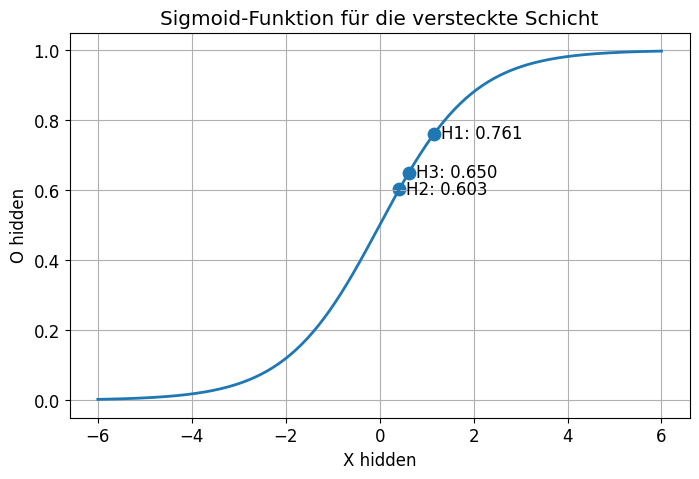

In [ ]:
#@title Diagramm: Sigmoid-Funktion für die versteckte Schicht { display-mode: "form" }
x_values = np.linspace(-6, 6, 300)
y_values = sigmoid(x_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_values, y_values, linewidth=2)
ax.scatter(X_hidden.flatten(), O_hidden.flatten(), s=80)

for index, (x_value, y_value) in enumerate(zip(X_hidden.flatten(), O_hidden.flatten()), start=1):
    ax.text(x_value + 0.15, y_value, f"H{index}: {y_value:.3f}", va="center")

ax.set_title("Sigmoid-Funktion für die versteckte Schicht")
ax.set_xlabel("X hidden")
ax.set_ylabel("O hidden")
ax.set_ylim(-0.05, 1.05)
plt.show()


## 10. Die zweite Gewichtsmatrix

Jetzt gehen die Werte aus der versteckten Schicht weiter zur Ausgabeschicht.

Dafür brauchen wir eine neue Gewichtsmatrix:

$W_{hidden\_output}$

Sie enthält die Gewichte von der **versteckten Schicht** zur **Ausgabeschicht**.

Auch hier gilt:

> Eine Zeile gehört zu einem Zielneuron in der Ausgabeschicht.

Das Ergebnis ist wieder eine Spaltenmatrix.


In [ ]:
#@title Tabelle: Gewichte pro Neuron (Zeile) { display-mode: "form" }
W_hidden_output = np.array([
    [0.3, 0.7, 0.5],
    [0.6, 0.5, 0.2],
    [0.8, 0.1, 0.9],
])

display(as_matrix_table(W_hidden_output,
                        row_prefix="Ziel O", col_prefix="Start H", decimals=1))
print(f"Form von W_hidden_output: {W_hidden_output.shape[0]}x{W_hidden_output.shape[1]}")

,Start H 1,Start H 2,Start H 3
Ziel O 1,0.3,0.7,0.5
Ziel O 2,0.6,0.5,0.2
Ziel O 3,0.8,0.1,0.9


Form von W_hidden_output: 3x3



## 11. Von der versteckten Schicht zur Ausgabeschicht

Jetzt ist $O_{\text{hidden}}$ die Eingabe für die letzte Schicht.

Wir runden $O_{\text{hidden}}$ auf drei Stellen.
So bleiben die Zahlen gut lesbar.
Ein Computer kann auch mit mehr Stellen weiterrechnen.

Wir rechnen:

$X_{output} = W_{hidden\_output} \cdot O_{hidden}$

Die Grössen sind:

$3x3 \cdot 3x1 = 3x1$

Danach wenden wir wieder Sigmoid an:

$O_{output} = sigmoid(X_{output})$

$O_{\text{output}}$ ist die letzte Ausgabe des Netzes.


In [ ]:
#@title Tabelle: Output der Rohen Summen (X), sowie nach der Sigmoidfunktion (O) { display-mode: "form" }
O_hidden_for_next = np.round(O_hidden, 3)
X_output = W_hidden_output @ O_hidden_for_next
O_output = sigmoid(X_output)

output_table = pd.DataFrame({
    "X output rohe Summe": np.round(X_output.flatten(), 3),
    "O output nach Sigmoid": np.round(O_output.flatten(), 3),
}, index=["Ausgabeneuron 1", "Ausgabeneuron 2", "Ausgabeneuron 3"])

display(output_table)

,X output rohe Summe,O output nach Sigmoid
Ausgabeneuron 1,0.975,0.726
Ausgabeneuron 2,0.888,0.708
Ausgabeneuron 3,1.254,0.778


In [ ]:
#@title Berechnungen der Ausgaben { display-mode: "form" }
print("Rechnung für X_output:")
print_matrix_product_steps(W_hidden_output, O_hidden_for_next, X_output, result_name="x_output_", value_decimals=3)

print("\nSigmoid für O_output:")
for index, x_value in enumerate(X_output.flatten(), start=1):
    output_value = sigmoid(x_value)
    print(f"O_output_{index} = sigmoid({x_value:.3f}) = {output_value:.3f}")

Rechnung für X_output:
x_output_1 = 0.3 * 0.761 + 0.7 * 0.603 + 0.5 * 0.65 = 0.975
x_output_2 = 0.6 * 0.761 + 0.5 * 0.603 + 0.2 * 0.65 = 0.888
x_output_3 = 0.8 * 0.761 + 0.1 * 0.603 + 0.9 * 0.65 = 1.254

Sigmoid für O_output:
O_output_1 = sigmoid(0.975) = 0.726
O_output_2 = sigmoid(0.888) = 0.708
O_output_3 = sigmoid(1.254) = 0.778



## 12. Das ganze Netz als Bild

Im Bild siehst du die drei Schichten.

Links stehen die Eingaben.

In der Mitte steht die versteckte Schicht.

Rechts steht die Ausgabeschicht.

Die Zahlen zwischen den Schichten zeigen:

- vor Sigmoid: \(X\)
- nach Sigmoid: \(O\)


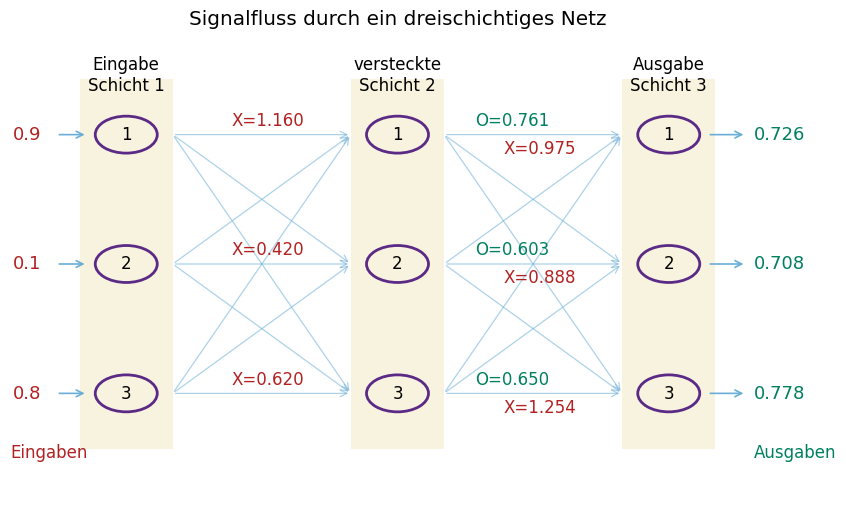

In [ ]:
#@title Signalfluss durch ein dreischichtiges Netz { display-mode: "form" }
def plot_three_layer_network(input_values, x_hidden, o_hidden, x_output, o_output):
    """Zeichnet ein einfaches Netz mit drei Schichten."""
    input_values = np.array(input_values).flatten()
    x_hidden = np.array(x_hidden).flatten()
    o_hidden = np.array(o_hidden).flatten()
    x_output = np.array(x_output).flatten()
    o_output = np.array(o_output).flatten()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x_positions = [0.15, 0.50, 0.85]
    y_positions = np.array([0.78, 0.50, 0.22])
    layer_titles = ["Eingabe\nSchicht 1", "versteckte\nSchicht 2", "Ausgabe\nSchicht 3"]

    layer_fill = ["#f7f0d6", "#f7f0d6", "#f7f0d6"]
    node_edge = "#5b2a86"
    arrow_color = "#6aaed6"
    x_color = "#b22222"
    o_color = "#008060"

    for x_pos, title, fill in zip(x_positions, layer_titles, layer_fill):
        rect = Rectangle((x_pos - 0.06, 0.10), 0.12, 0.80,
                         facecolor=fill, edgecolor="none", alpha=0.8)
        ax.add_patch(rect)
        ax.text(x_pos, 0.95, title, ha="center", va="top", fontsize=12)

    # Verbindungen zeichnen
    for y_start in y_positions:
        for y_end in y_positions:
            ax.annotate("", xy=(x_positions[1] - 0.06, y_end), xytext=(x_positions[0] + 0.06, y_start),
                        arrowprops=dict(arrowstyle="->", linewidth=0.9, color=arrow_color, alpha=0.55))
            ax.annotate("", xy=(x_positions[2] - 0.06, y_end), xytext=(x_positions[1] + 0.06, y_start),
                        arrowprops=dict(arrowstyle="->", linewidth=0.9, color=arrow_color, alpha=0.55))

    # Knoten und Werte
    for i, y in enumerate(y_positions):
        ax.add_patch(Circle((x_positions[0], y), 0.04, fill=False, linewidth=2, edgecolor=node_edge))
        ax.text(x_positions[0], y, str(i + 1), ha="center", va="center")
        ax.text(0.04, y, f"{input_values[i]:.1f}", ha="right", va="center", color=x_color, fontsize=13)
        ax.annotate("", xy=(x_positions[0] - 0.05, y), xytext=(0.06, y),
                    arrowprops=dict(arrowstyle="->", color=arrow_color, linewidth=1.2))

        ax.add_patch(Circle((x_positions[1], y), 0.04, fill=False, linewidth=2, edgecolor=node_edge))
        ax.text(x_positions[1], y, str(i + 1), ha="center", va="center")
        ax.text(0.38, y + 0.03, f"X={x_hidden[i]:.3f}", ha="right", va="center", color=x_color, fontsize=12)
        ax.text(0.60, y + 0.03, f"O={o_hidden[i]:.3f}", ha="left", va="center", color=o_color, fontsize=12)

        ax.add_patch(Circle((x_positions[2], y), 0.04, fill=False, linewidth=2, edgecolor=node_edge))
        ax.text(x_positions[2], y, str(i + 1), ha="center", va="center")
        ax.text(0.73, y - 0.03, f"X={x_output[i]:.3f}", ha="right", va="center", color=x_color, fontsize=12)
        ax.text(0.96, y, f"{o_output[i]:.3f}", ha="left", va="center", color=o_color, fontsize=13)
        ax.annotate("", xy=(0.95, y), xytext=(x_positions[2] + 0.05, y),
                    arrowprops=dict(arrowstyle="->", color=arrow_color, linewidth=1.2))

    ax.text(0.05, 0.08, "Eingaben", ha="center", color=x_color)
    ax.text(0.96, 0.08, "Ausgaben", ha="left", color=o_color)
    ax.set_title("Signalfluss durch ein dreischichtiges Netz")
    plt.show()

plot_three_layer_network(I, X_hidden, O_hidden, X_output, O_output)


## 13. Alles in einer Funktion

Jetzt packen wir die ganze Rechnung in eine Funktion.

Das ist praktisch.
Dann können wir andere Eingaben testen.


In [ ]:
#@title Alles als Vektoren oder Matrizen dargestellt { display-mode: "form" }
def run_three_layer_network(input_matrix, w_input_hidden, w_hidden_output):
    """Berechnet alle Schritte in einem dreischichtigen Netz."""
    x_hidden = w_input_hidden @ input_matrix
    o_hidden = sigmoid(x_hidden)
    o_hidden_for_next = np.round(o_hidden, 3)
    x_output = w_hidden_output @ o_hidden_for_next
    o_output = sigmoid(x_output)

    return {
        "I": input_matrix,
        "X_hidden": x_hidden,
        "O_hidden": o_hidden,
        "X_output": x_output,
        "O_output": o_output,
    }

result = run_three_layer_network(I, W_input_hidden, W_hidden_output)

for name, matrix in result.items():
    print(name)
    print(np.round(matrix, 3))
    print()

I
[[0.9]
 [0.1]
 [0.8]]

X_hidden
[[1.16]
 [0.42]
 [0.62]]

O_hidden
[[0.761]
 [0.603]
 [0.65 ]]

X_output
[[0.975]
 [0.888]
 [1.254]]

O_output
[[0.726]
 [0.708]
 [0.778]]




## 14. Kleines Experiment

Ändere die Werte in `test_input`.

Alle Werte sollten zwischen 0 und 1 liegen.

Beobachte dann:

- Was ändert sich in \(X_{hidden}\)?
- Was ändert sich in \(O_{hidden}\)?
- Was ändert sich am Schluss in \(O_{output}\)?


In [ ]:
test_input = np.array([
    [0.2], # Hier Eingabe 1 ändern, Werte zwischen 0 und 1 (Standard 0.2)
    [0.9], # Hier Eingabe 2 ändern, Werte zwischen 0 und 1 (Standard 0.9)
    [0.4], # Hier Eingabe 3 ändern, Werte zwischen 0 und 1 (Standard 0.4)
])

,I,X hidden,O hidden,X output,O output
Neuron 1,0.2,0.61,0.648,1.018,0.735
Neuron 2,0.9,0.84,0.698,0.872,0.705
Neuron 3,0.4,0.71,0.670,1.191,0.767


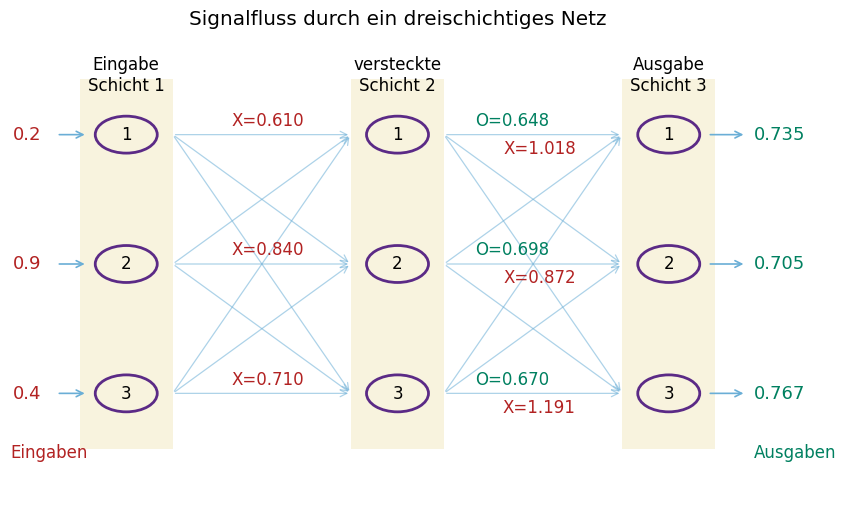

In [ ]:
#@title Werte für das Experiment neu berechnen { display-mode: "form" }
test_result = run_three_layer_network(test_input, W_input_hidden, W_hidden_output)

experiment_table = pd.DataFrame({
    "I": np.round(test_result["I"].flatten(), 3),
    "X hidden": np.round(test_result["X_hidden"].flatten(), 3),
    "O hidden": np.round(test_result["O_hidden"].flatten(), 3),
    "X output": np.round(test_result["X_output"].flatten(), 3),
    "O output": np.round(test_result["O_output"].flatten(), 3),
}, index=["Neuron 1", "Neuron 2", "Neuron 3"])

display(experiment_table)
plot_three_layer_network(test_input, test_result["X_hidden"], test_result["O_hidden"],
                         test_result["X_output"], test_result["O_output"])


## 15. Merksätze

Ein dreischichtiges Netz rechnet in zwei grossen Schritten.

**Schritt 1: von Eingabe zu versteckter Schicht**

$X_{hidden} = W_{input\_hidden} \cdot I$

$O_{hidden} = sigmoid(X_{hidden})$

**Schritt 2: von versteckter Schicht zu Ausgabeschicht**

$X_{output} = W_{hidden\_output} \cdot O_{hidden}$

$O_{output} = sigmoid(X_{output})$

Ganz kurz:

> Matrix mal Eingabe gibt rohe Summen.

> Sigmoid macht daraus Ausgaben zwischen 0 und 1.



## 16. Mini-Aufgaben

Beantworte die Fragen in eigenen Worten.

1. Warum heisst die mittlere Schicht versteckte Schicht?
2. Was steht in einer Gewichtsmatrix?
3. Was bedeutet $O_{\text{hidden}}$?
4. Warum verwenden wir die Sigmoid-Funktion?
5. Welche Rechnung kommt direkt vor $O_{\text{output}}$?


Copyright 2026 [Markus Ineichen](mailto:markus.ineichen1@sluz.ch)

Code licence: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)